In [1]:
import numpy as np
import pandas as pd
import pickle as pk
from brian2 import *
from time import sleep
import os, sys, shutil
from random import randint
import scipy.interpolate as itp
from itertools import product, chain, starmap
from multiprocessing import Pool

sys.path.insert(0, '../../scripts_analysis')
sys.path.insert(0, '../../model_steps')
from peaks import *
from analysis import *

## MCell analysis

In [2]:
setupLoc = '../../model_mcell'
resultPath = "../../data/syt7KO/"
dataPath = "../../data/control/"

tempdirs = np.genfromtxt(os.path.join(setupLoc, 'representative_designs.txt'), dtype=str)

for i,d in enumerate(tempdirs): print(i, d)

0 nVDCC_2_dVAZ_60_nAZ_15_RRP_35_ISI_20_nAP_10
1 nVDCC_3_dVAZ_100_nAZ_29_RRP_55_ISI_20_nAP_10
2 nVDCC_3_dVAZ_60_nAZ_9_RRP_20_ISI_20_nAP_10
3 nVDCC_3_dVAZ_80_nAZ_35_RRP_30_ISI_20_nAP_10
4 nVDCC_4_dVAZ_100_nAZ_19_RRP_50_ISI_20_nAP_10
5 nVDCC_4_dVAZ_120_nAZ_25_RRP_55_ISI_20_nAP_10
6 nVDCC_4_dVAZ_120_nAZ_33_RRP_50_ISI_20_nAP_10
7 nVDCC_4_dVAZ_80_nAZ_21_RRP_30_ISI_20_nAP_10
8 nVDCC_5_dVAZ_100_nAZ_11_RRP_50_ISI_20_nAP_10
9 nVDCC_5_dVAZ_120_nAZ_15_RRP_50_ISI_20_nAP_10
10 nVDCC_5_dVAZ_120_nAZ_23_RRP_40_ISI_20_nAP_10
11 nVDCC_5_dVAZ_120_nAZ_35_RRP_25_ISI_20_nAP_10
12 nVDCC_5_dVAZ_220_nAZ_35_RRP_50_ISI_20_nAP_10
13 nVDCC_5_dVAZ_80_nAZ_21_RRP_10_ISI_20_nAP_10
14 nVDCC_5_dVAZ_80_nAZ_29_RRP_10_ISI_20_nAP_10
15 nVDCC_6_dVAZ_140_nAZ_25_RRP_30_ISI_20_nAP_10
16 nVDCC_6_dVAZ_160_nAZ_19_RRP_55_ISI_20_nAP_10
17 nVDCC_6_dVAZ_160_nAZ_35_RRP_25_ISI_20_nAP_10
18 nVDCC_6_dVAZ_200_nAZ_29_RRP_50_ISI_20_nAP_10
19 nVDCC_6_dVAZ_80_nAZ_17_RRP_10_ISI_20_nAP_10
20 nVDCC_7_dVAZ_100_nAZ_33_RRP_5_ISI_20_nAP_10
21 nVDCC_7_

In [3]:
# syt7KO = 'syt7KO'
# dataPath = "/media/nishant/4tb/output/MFB/syt7KO/"
# resultPath = "/home/nishant/lab/MFB/results/syt7KO/"

# dirs = [a for a in getDirs(resultPath, sstr='nVDCC') if "ISI_20" in a]
# dirs.sort(key=natural_keys)
# dirs = np.array(dirs)[:]

# for i,d in enumerate(dirs): print(i, d)

## AZ simulation in STEPS

In [5]:
from MFB_model import *
mdl, sim, r = get_MFB_model(syt7KO='syt7KO')

syt7KO


## Testing a single trail with STEPS

In [ ]:
CaFile = dataPath + tempdirs[0] + '/CaConc.dat'
CaData = np.genfromtxt(CaFile, skip_header=1, unpack=True)
print(tempdirs[0], CaData.shape, CaData[0][0], CaData[0][-1])
T = np.arange(CaData[0][0], CaData[0][-1], 1e-5)
CaInterp = itp.interp1d(CaData[0], CaData[1])
CaInterpData = CaInterp(T)

resAZ, vesRel = simAZ(T, CaInterpData, sim, r)

nFig = 3
figure, ax = plt.subplots(nFig, figsize=(15, 4*nFig), sharex=True)
figure.subplots_adjust(hspace=0.1)
labelfontsize = 13

for mol in azMolName[:18]:
    i = azMolName.index(mol)
    ax[1].plot(T, resAZ[:,i], label=mol)
ax[1].set_ylabel('AZ states (num)', fontsize=labelfontsize)
ax[1].legend(bbox_to_anchor=(1, 1), loc='upper left', ncol=2)

vesRelSync  = np.sum(vesRel[:,:3], axis=1)
vesRelAsync = np.sum(vesRel[:,3:-1], axis=1)
vesRelSpont = vesRel[:,-1]
vesRelTot   = np.sum(vesRel, axis=1)

ax[2].plot(T, vesRelSync, label='sync')
ax[2].plot(T, vesRelAsync, label='async')
ax[2].plot(T, vesRelSpont, label='spont')
ax[2].plot(T, vesRelTot, label='total')
    
ax[2].set_ylabel('Vesicles released', fontsize=labelfontsize)
ax[2].legend()

peaks = detect_peaks(vesRelTot, edge='rising', show=False)
ax[2].plot(T[peaks], vesRelTot[peaks], '+', mfc=None, mec='r', mew=2, ms=15)
#print(T[peaks])

plt.show()

In [7]:
def runAZTrials(CaData, RRP):
    vesData = {}

    resAZ, vesRel = simAZ(CaData[0], CaData[1], sim, r, RRP=RRP)
    vesRelSync  = np.sum(vesRel[:,:3], axis=1)
    vesRelAsync = np.sum(vesRel[:,3:-2], axis=1)
    vesRelSpont  = vesRel[:,-1]

    # vesRelTot = np.sum(vesRel, axis=1)
    #print(vesRelSync, vesRelAsync, vesRelSpont)

    pksSync = detect_peaks(vesRelSync, edge='rising', show=False)
    pksAsync = detect_peaks(vesRelAsync, edge='rising', show=False)
    pksSpont = detect_peaks(vesRelSpont, edge='rising', show=False)

    vesData.update({'sync' : list(CaData[0,pksSync])})
    vesData.update({'async': list(CaData[0,pksAsync])})
    vesData.update({'spont': list(CaData[0,pksSpont])})

    return vesData, resAZ

In [8]:
def getVesRel(dir, resultPath, fname='CaConc.dat', trials=2000, pools=False):
    nAZ = int(getSimInfo(dir, 'nAZ'))
    RRP = int(getSimInfo(dir, 'RRP'))
    
    CaFile = os.path.join(dataPath, dir, fname)
    CaData = np.genfromtxt(CaFile, unpack=True, skip_header=1) # in uM

    if not os.path.exists(os.path.join(resultPath, dir)):
        os.makedirs(os.path.join(resultPath,dir))
    
    
    if pools:
        p = Pool(pools)
    else:
        p = Pool()
        
    vesData = {}
    desc = str([int(a) for a in re.findall(r'\d+', dir)[:-1]])
    for iCa in tq(range(1,nAZ+1), desc=desc):
        info = product([CaData[(0,iCa),:]], [RRP]*trials)
        data = p.starmap(runAZTrials, info)

        vesSync  = [dd[0]['sync'] for dd in data]
        vesAsync  = [dd[0]['async'] for dd in data]
        vesSpont  = [dd[0]['spont'] for dd in data]
        vesData.update({f'AZ{iCa}': {'sync': vesSync, 'async':vesAsync, 'spont':vesSpont}})
        
        resAZ = np.array([dd[1] for dd in data])
        AZstates = np.mean(resAZ, axis=0)
        fAZ = os.path.join(resultPath, dir, f'AZ_{iCa}.dat')
        AZdata = np.hstack((np.array([CaData[0]]).T, AZstates))
        np.savetxt(fAZ, AZdata, fmt=['%0.5f']+['%0.4f']*18, delimiter="\t")
        
    #print(vesData)
    p.close()
    return vesData


# nVDCC, dVAZ, nAZ, RRP = [int(getSimInfo(tempdirs[0], key, skip=0)) for key in ['nVDCC', 'dVAZ', 'nAZ', 'RRP']]
# vesData = getVesRel(tempdirs[0], RRP=RRP, resultPath=resultPath, trials=5, pools=5)

In [ ]:
for d in tq(tempdirs[:]):
    #try:
    vesData = getVesRel(d, resultPath=resultPath, trials=2000, pools=35)
    with open(os.path.join(resultPath, d, 'vesData.dat'), "wb") as outfile:
        pk.dump(vesData, outfile)

100%|██████████| 44/44 [26:18:10<00:00, 2152.06s/it]


## Get Vesicle Release Statistics

In [ ]:
for d in tq(tempdirs[:1]):
    relStat(d, resultPath, resample=100)
    # try:
    #     relStat(d, resultPath, resample=100)
    # except: 
    #     print(f'Error in {dir}')

100%|██████████| 1/1 [00:06<00:00,  6.64s/it]


In [4]:
### parallely
jobInfo = list(product(tempdirs[:], [resultPath], [1000]))
#print(info)

p = Pool(25)
p.starmap(relStat, jobInfo)
p.close()

Resampling [11, 220, 27, 10, 20]: 100%|██████████| 1000/1000 [01:39<00:00, 10.09it/s]


## EPSC calculations

In [ ]:
for d in dirs[:]:
    resultDir = os.path.join(resultPath, d)
    tpoints, avgEPSC = getAvgEPSC(resultDir, 'vesData.dat')
    fepsc = os.path.join(resultPath, d, 'epsc.dat')
    #np.savetxt(fepsc, np.array([tpoints, avgEPSC]).T, fmt=['%0.5f']+['%0.2f'], delimiter="\t")
    #plt.plot(tpoints, avgEPSC)

    allapTimes = {}
    for APth in range(75, 201, 25):
        apTimes = getAPTimes(resultDir, 'vesData.dat', APth=APth)
        allapTimes.update({APth: apTimes})
    #with open(os.path.join(resultPath, d, 'apTimes.dat'), "wb") as outfile:
        #pk.dump(allapTimes, outfile)
    print(d)

## AP generation and EPSC calculations

In [229]:
%%time
sigma = 1 # noise amplitude
tstep = 0.1 # ms
for d, ttt in product(dirs, ['']):
    resultDir = os.path.join(resultPath, d)
    indices, vesreltimes, nCA3 = getVesInput(resultDir, ttt=ttt, delta=tstep/1000)

    start_scope()
    defaultclock.dt = tstep*ms

    CA3inp = SpikeGeneratorGroup(nCA3, indices, vesreltimes*second)
    #nCA3 = 4; CA3inp = SpikeGeneratorGroup(nCA3, indices[:35], vesreltimes[:35]*second)

    ## CA3 neuron
    V_L = -60.0*mV
    V_thr = -42.0*mV
    V_reset = -65.0*mV

    Cm = 0.025*nF # membrane capacitance
    gm = 0.5*nS  # membrane leak
    tau_rp = 5.0*ms # refractory period 

    gmax_ampa = 1*nsiemens # max AMPA conductance
    tau_g_ampa = 10*ms
    tau_d = 50*ms # desensitisation
    
    tau_nt = 1*ms
    
    A1, A2 = 5/(mM*ms), 0.18/ms
    g_gabaA = 1*nsiemens
    V_gabaA = -85*mV

    B1, B2 = 0.09/(mM*ms), 0.0012/ms
    K1, K2 = 0.18/ms, 0.034/ms
    g_gabaB = 3*nsiemens
    V_gabaB = -95*mV


    eqnCA3 = '''
    dv/dt = (- gm*(v - V_L) - I_ampa - I_gabaA - I_gabaB) / Cm : volt (unless refractory)
    I_ampa = gmax_ampa*g_ampa*d*v : amp
    dg_ampa/dt = -g_ampa/tau_g_ampa : 1
    dd/dt = (1-d)/tau_d : 1

    I_gabaA = g_gabaA*f_gabaA*(v - V_gabaA): amp
    df_gabaA/dt = A1*nt*(1 - f_gabaA) - A2*f_gabaA : 1

    I_gabaB = g_gabaB * G**4/(G**4+100)*(v - V_gabaB): amp
    df_gabaB/dt = B1*nt*(1 - f_gabaB) - B2*f_gabaB : 1
    dG/dt = K1*f_gabaB - K2*G: 1

    nt : mM
    '''

    CA3 = NeuronGroup(nCA3, eqnCA3, threshold='v > V_thr', reset='v = V_reset', 
                      refractory=tau_rp, method='euler')
    CA3.v = V_L
    CA3.d = 1
    
    ## DG input spikes for interneurons
    simInfo = getSimInfo(d)
    ISI, nAP = int(simInfo['ISI']), int(simInfo['nAP'])
    try: bISI, nB = int(simInfo['bISI']), int(simInfo['nB'])
    except KeyError: bISI, nB = 0, 1
    stimTimes = np.sort([1.5 + na*ISI + nb*bISI for na,nb in product(range(nAP), range(nB))])/1000
    sptimes = np.array(stimTimes)*second
    
    DG = SpikeGeneratorGroup(1, np.zeros(sptimes.shape), sptimes)
    
    ## Inhibitory Interneuron
    Cm_in = 0.1*nF # membrane capacitance
    gm_in = 4.0*nS # membrane leak
    tau_rp_in = 1*ms # refractory period
    Vin_rest = -57.0*mV
    Vin_thr, Vin_reset = -50.0*mV, -60.0*mV
    gInmax_ampa = 4*nS
    tau_gIn_ampa = 2*ms

    eqnIn = '''
    dv/dt = (- gm_in*(v - Vin_rest) - I_ampa)/Cm_in + sigma*sqrt(1/(1*ms))*xi*mV: volt (unless refractory)
    I_ampa = gInmax_ampa*gIn_ampa*v : amp
    dgIn_ampa/dt = -gIn_ampa/tau_gIn_ampa : 1
    '''
    
    nIn = 1000
    In = NeuronGroup(nIn, eqnIn, threshold='v > Vin_thr', reset='v = Vin_reset',
                       refractory=tau_rp_in, method='euler')
    In.v = Vin_rest
    
    ### Synapses
    on_preCA3 = 'g_ampa += 1; d -= 0*d'
    S_CA3inp_CA3 = Synapses(CA3inp, CA3, on_pre=on_preCA3)
    S_CA3inp_CA3.connect('i==j')
    
    on_preIn = 'gIn_ampa += 1'
    S_DG_In = Synapses(DG, In, delay=0.1*ms, on_pre=on_preIn)
    S_DG_In.connect(i=0, j=range(nIn))
    
    ## In ---> CA3 synapse
    eqnSIn = '''
    dnT/dt = -nT/tau_nt: mM (clock-driven)
    nt_post = nT : mM (summed) '''
    
    kk = 10 # average number of inputs a CA3 neuron receives
    S_In_CA3 = Synapses(In, CA3, model=eqnSIn, method='euler', delay=0.1*ms, on_pre='nT += 0.5*mM')
    S_In_CA3.connect(p=kk/nIn)
    
    ### Monitors
    stMCA3 = StateMonitor(CA3, variables=True, record=True)
    spMCA3 = SpikeMonitor(CA3)
    
    spMinp = SpikeMonitor(CA3inp)
    
    stMIn = StateMonitor(In, variables=True, record=True)
    spMIn = SpikeMonitor(In)

    spMDG = SpikeMonitor(DG)
    
    stMS = StateMonitor(S_In_CA3, variables=True, record=True)

    runt = 210 # ms
    run(runt*ms)
    
    avgEPSC = -np.mean((stMCA3.I_ampa + stMCA3.I_gabaA + stMCA3.I_gabaB)/pamp, axis=0)
    fepsc = os.path.join(resultDir, ttt+'epsc.dat')
    np.savetxt(fepsc, np.array([stMCA3.t/second, avgEPSC]).T, fmt=['%0.5f']+['%0.2f'], delimiter="\t")

    apTimes = [a/second for a in list(spMCA3.spike_trains().values())]
    with open(os.path.join(resultDir, ttt+'apTimes.dat'), "wb") as outfile:
        pk.dump(apTimes, outfile)

CPU times: user 4min 34s, sys: 26.6 s, total: 5min
Wall time: 5min 7s


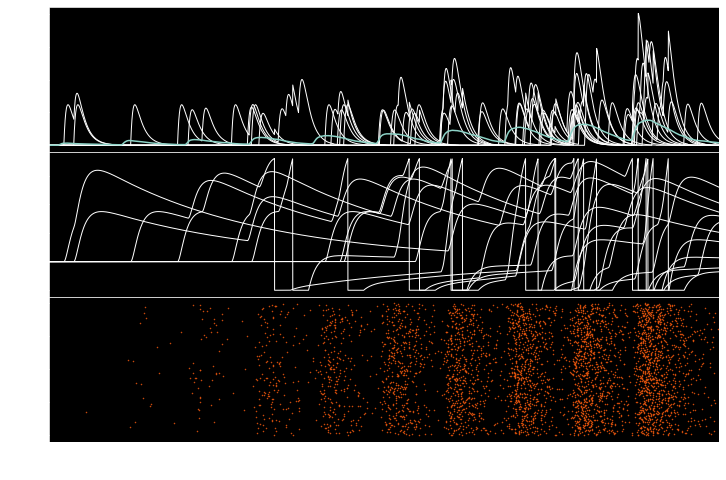

In [6]:
f, ax = plt.subplots(3, sharex=True, figsize=(12,8))
f.subplots_adjust(wspace=0., hspace=0.)
lw = 1

for i in range(10):
    ax[0].plot(stM.t/ms, -stM.I_AMPA[i]/pamp, color=cpall[-1], lw=lw, label='I_AMPA')
    ax[1].plot(stM.t/ms, stM.v[i]/mV, color=cpall[-1], lw=lw, label='v')
ax[0].plot(stM.t/ms, avgEPSC, label='I_AMPA')
ax[0].set_ylabel('I_AMPA (pA)')
ax[1].set_ylabel('mV')
ax[0].set_xlim(0,runt/ms)
#ax[0].legend()

ax[2].plot(spM.t/ms, spM.i, '.k', color=cpall[2], ms=1)
ax[2].set_xlabel('Time (ms)');

## Extra Stuff

In [230]:
%%time
sigma = 0.2 # noise amplitude
tstep = 0.1 # ms
for d, ttt in product(dirs, ['']):
    resultDir = os.path.join(resultPath, d)
    indices, vesreltimes, nCA3 = getVesInput(resultDir, ttt=ttt, delta=tstep/1000)

    start_scope()
    defaultclock.dt = tstep*ms

    CA3inp = SpikeGeneratorGroup(nCA3, indices, vesreltimes*second)
    #nCA3 = 4; CA3inp = SpikeGeneratorGroup(nCA3, indices[:35], vesreltimes[:35]*second)

    ## CA3 neuron
    V_L = -60.0*mV
    V_thr = -42.0*mV
    V_reset = -65.0*mV

    Cm = 0.025*nF # membrane capacitance
    gm = 0.5*nS  # membrane leak
    tau_rp = 5.0*ms # refractory period 

    gmax_ampa = 1*nsiemens # max AMPA conductance
    tau_g_ampa = 10*ms
    tau_d = 50*ms # desensitisation
    
    tau_nt = 1*ms
    
    A1, A2 = 5/(mM*ms), 0.18/ms
    g_gabaA = 1*nsiemens
    V_gabaA = -85*mV

    B1, B2 = 0.09/(mM*ms), 0.0012/ms
    K1, K2 = 0.18/ms, 0.034/ms
    g_gabaB = 3*nsiemens
    V_gabaB = -95*mV


    eqnCA3 = '''
    dv/dt = (- gm*(v - V_L) - I_ampa - I_gabaA - I_gabaB) / Cm : volt (unless refractory)
    I_ampa = gmax_ampa*g_ampa*d*v : amp
    dg_ampa/dt = -g_ampa/tau_g_ampa : 1
    dd/dt = (1-d)/tau_d : 1

    I_gabaA = g_gabaA*f_gabaA*(v - V_gabaA): amp
    df_gabaA/dt = A1*nt*(1 - f_gabaA) - A2*f_gabaA : 1

    I_gabaB = g_gabaB * G**4/(G**4+100)*(v - V_gabaB): amp
    df_gabaB/dt = B1*nt*(1 - f_gabaB) - B2*f_gabaB : 1
    dG/dt = K1*f_gabaB - K2*G: 1

    nt : mM
    '''

    CA3 = NeuronGroup(nCA3, eqnCA3, threshold='v > V_thr', reset='v = V_reset', 
                      refractory=tau_rp, method='euler')
    CA3.v = V_L
    CA3.d = 1
    
    ## DG input spikes for interneurons
    simInfo = getSimInfo(d)
    ISI, nAP = int(simInfo['ISI']), int(simInfo['nAP'])
    try: bISI, nB = int(simInfo['bISI']), int(simInfo['nB'])
    except KeyError: bISI, nB = 0, 1
    stimTimes = np.sort([1.5 + na*ISI + nb*bISI for na,nb in product(range(nAP), range(nB))])/1000
    sptimes = np.array(stimTimes)*second
    
    DG = SpikeGeneratorGroup(1, np.zeros(sptimes.shape), sptimes)
    
    ## Inhibitory Interneuron
    Cm_in = 0.1*nF # membrane capacitance
    gm_in = 4.0*nS # membrane leak
    tau_rp_in = 1*ms # refractory period
    Vin_rest = -57.0*mV
    Vin_thr, Vin_reset = -50.0*mV, -60.0*mV
    gInmax_ampa = 5*nS
    tau_gIn_ampa = 2*ms

    eqnIn = '''
    dv/dt = (- gm_in*(v - Vin_rest) - I_ampa)/Cm_in + sigma*sqrt(1/(1*ms))*xi*mV: volt (unless refractory)
    I_ampa = gInmax_ampa*gIn_ampa*v : amp
    dgIn_ampa/dt = -gIn_ampa/tau_gIn_ampa : 1
    '''
    
    nIn = 1000
    In = NeuronGroup(nIn, eqnIn, threshold='v > Vin_thr', reset='v = Vin_reset',
                       refractory=tau_rp_in, method='euler')
    In.v = '-60*mV + rand()*10*mV'
    
    ### Synapses
    on_preCA3 = 'g_ampa += 1; d -= 0*d'
    S_CA3inp_CA3 = Synapses(CA3inp, CA3, on_pre=on_preCA3)
    S_CA3inp_CA3.connect('i==j')
    
    on_preIn = 'gIn_ampa += 1'
    S_DG_In = Synapses(DG, In, delay=0.1*ms, on_pre=on_preIn)
    S_DG_In.connect(i=0, j=range(nIn))
    
    ## In ---> CA3 synapse
    eqnSIn = '''
    dnT/dt = -nT/tau_nt: mM (clock-driven)
    nt_post = nT : mM (summed) '''
    
    kk = 10 # average number of inputs a CA3 neuron receives
    S_In_CA3 = Synapses(In, CA3, model=eqnSIn, method='euler', delay=0.1*ms, on_pre='nT += 0.5*mM')
    S_In_CA3.connect(p=kk/nIn)
    
    ### Monitors
    stMCA3 = StateMonitor(CA3, variables=True, record=True)
    spMCA3 = SpikeMonitor(CA3)
    
    spMinp = SpikeMonitor(CA3inp)
    
    stMIn = StateMonitor(In, variables=True, record=True)
    spMIn = SpikeMonitor(In)

    spMDG = SpikeMonitor(DG)
    
    stMS = StateMonitor(S_In_CA3, variables=True, record=True)

    runt = 210 # ms
    run(runt*ms)
    
    avgEPSC = -np.mean((stMCA3.I_ampa + stMCA3.I_gabaA + stMCA3.I_gabaB)/pamp, axis=0)
    fepsc = os.path.join(resultDir, ttt+'epsc.dat')
    np.savetxt(fepsc, np.array([stMCA3.t/second, avgEPSC]).T, fmt=['%0.5f']+['%0.2f'], delimiter="\t")

    apTimes = [a/second for a in list(spMCA3.spike_trains().values())]
    with open(os.path.join(resultDir, ttt+'apTimes.dat'), "wb") as outfile:
        pk.dump(apTimes, outfile)

CPU times: user 5min 13s, sys: 28.9 s, total: 5min 42s
Wall time: 5min 47s


CPU times: user 510 ms, sys: 96.4 ms, total: 606 ms
Wall time: 604 ms


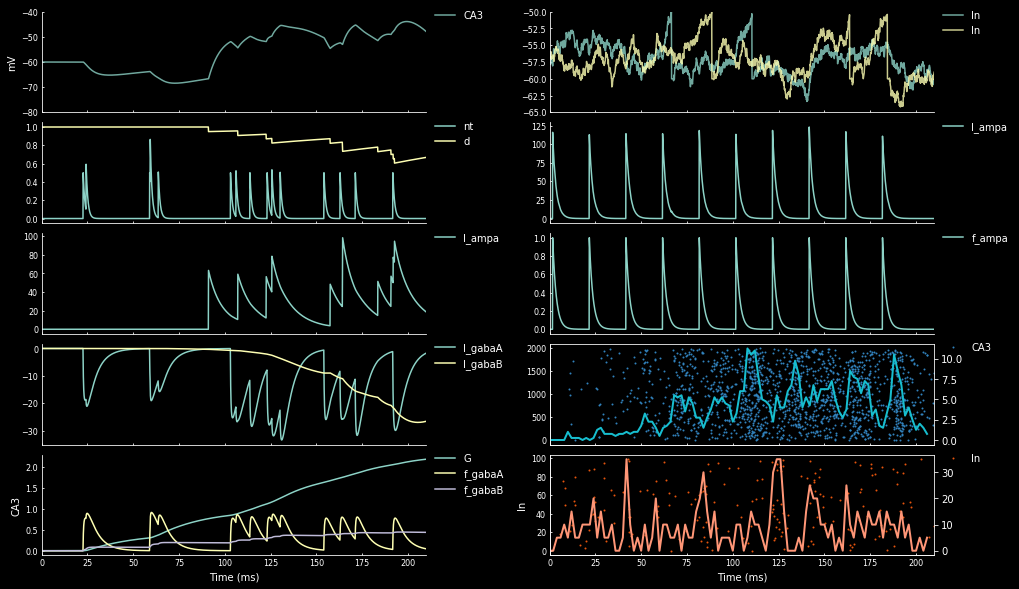

In [227]:
%%time
f, ax = plt.subplots(5, 2, sharex=True, figsize=(16,10))
f.subplots_adjust(wspace=0.32, hspace=0.1)
ax31t, ax41t = ax[3,1].twinx(), ax[4,1].twinx()
axt = [ax31t, ax41t]

ax[0,0].plot(stMCA3.t/ms, stMCA3.v[:1].T/mV, alpha=0.8, label='CA3')
ax[0,0].set_ylabel('mV')
ax[0,0].set_ylim(-80,-40)

ax[1,0].plot(stMCA3.t/ms, stMCA3.nt[:1].T, label='nt')
ax[1,0].plot(stMCA3.t/ms, stMCA3.d[:1].T, label='d')

ax[2,0].plot(stMCA3.t/ms, -stMCA3.I_ampa[:1].T/pamp, label='I_ampa')
ax[3,0].plot(stMCA3.t/ms, -stMCA3.I_gabaA[:1].T/pamp, label='I_gabaA')
ax[3,0].plot(stMCA3.t/ms, -stMCA3.I_gabaB[:1].T/pamp, label='I_gabaB')

ax[4,0].plot(stMCA3.t/ms, stMCA3.G[:1].T, label='G')
ax[4,0].plot(stMCA3.t/ms, stMCA3.f_gabaA[:1].T, label='f_gabaA')
ax[4,0].plot(stMCA3.t/ms, stMCA3.f_gabaB[:1].T, label='f_gabaB')

apratet, aprate = getSpikeRate(spMCA3, nCA3, runt=runt, bindt=2)
ax[3,1].plot(spMCA3.t/ms, spMCA3.i, '.', color=cppaired[0], ms=2, label='CA3')
ax31t.plot(apratet, aprate, color=cppaired[1], lw=2)
ax[4,0].set_ylabel('CA3')

ax[0,1].plot(stMIn.t/ms, stMIn.v[:2].T/mV, alpha=0.8, label='In')
ax[0,1].set_ylim(-65,-50)

ax[1,1].plot(stMIn.t/ms, -stMIn.I_ampa[:1].T/pamp, label='I_ampa')

ax[2,1].plot(stMIn.t/ms, stMIn.gIn_ampa[:1].T, label='f_ampa')

apratet, aprate = getSpikeRate(spMIn, nIn, runt=runt, bindt=2)
ax[4,1].plot(spMIn.t/ms, spMIn.i, '.', color=cppaired[2], ms=2, label='In')
ax41t.plot(apratet, aprate, color=cppaired[3], lw=2)
ax[4,1].set_ylabel('In')

[axis.set_xlabel('Time (ms)') for axis in ax[-1,:]]
for axis in list(ax.ravel()):# + axt:
    axis.set_xlim(0, runt)
    axis.spines["right"].set_visible(False)
    axis.spines["top"].set_visible(False)
    axis.tick_params(axis=u'both', which=u'both', length=2, direction='in', labelsize=8)
    axis.legend(frameon=False, bbox_to_anchor=(1.0, 0.9, 0.3, 0.2), loc='upper left')

In [ ]:
def visualise_connectivity(S):
    Ns = len(S.source)
    Nt = len(S.target)
    figure(figsize=(10, 6))
    subplot(121)
    plot(zeros(Ns), arange(Ns), 'ok', ms=10, color='w')
    plot(ones(Nt), arange(Nt), 'ok', ms=10, color='w')
    for i, j in zip(S.i, S.j):
        plot([0, 1], [i, j], '-k', color='w')
    xticks([0, 1], ['Source', 'Target'])
    ylabel('Neuron index')
    xlim(-0.1, 1.1)
    ylim(-1, max(Ns, Nt))
    subplot(122)
    plot(S.i, S.j, 'ok', color='w')
    xlim(-1, Ns)
    ylim(-1, Nt)
    xlabel('Source neuron index')
    ylabel('Target neuron index')
    
visualise_connectivity(S_In_CA3)

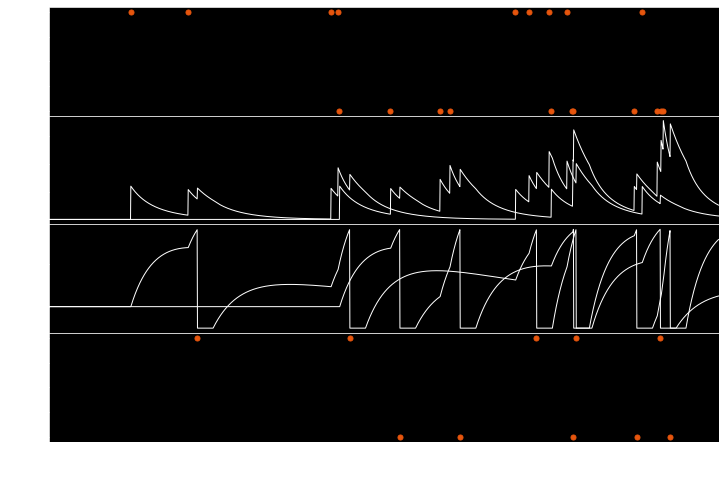

In [54]:
f, ax = plt.subplots(4, sharex=True, figsize=(12,8))
f.subplots_adjust(wspace=0., hspace=0.)
lw = 1

for i in range(2):
    ax[1].plot(stM.t/ms, -stM.I_ampa[i]/pamp, color=cpall[-1], lw=lw, label='I_ampa')
    ax[2].plot(stM.t/ms, stM.v[i]/mV, color=cpall[-1], lw=lw, label='v')
#ax[1].plot(stM.t/ms, avgEPSC, label='I_AMPA')
ax[1].set_ylabel('I_ampa (pA)')
ax[2].set_ylabel('mV')
ax[1].set_xlim(0,runt/ms)
#ax[1].legend()

ax[0].plot(spMinp.t/ms, spMinp.i, '.k', color=cpall[2], ms=10)
ax[3].plot(spM.t/ms, spM.i, '.k', color=cpall[2], ms=10)
ax[3].set_xlabel('Time (ms)');

In [218]:
d = dirs[16]
resultDir = os.path.join(resultPath, d)
    
def getVesInput(resultDir, ttt='', delta=1e-4):
    inf = os.path.join(resultDir, ttt+'vesData.dat')
    with open(inf, "rb") as infile:
        vesData = pk.load(infile)

    df = pd.io.json.json_normalize(vesData, sep='_')    
    df = df.to_dict(orient='records')[0]
    seeds = len(df['AZ1_sync'])
    emptyKeys = []
    for k,v in df.items():
        if all([not a for a in v]):
            emptyKeys.append(k)
    for e in emptyKeys:
        df.pop(e)

    vrel = [[] for _ in range(seeds)]
    for vs in df.values():
        for i,v in enumerate(vs):
            vrel[i] += v
    for i,vr in enumerate(vrel):
        vrel[i] = np.sort(vr)
        
    #'''
    mins = [delta]
    while min(mins)<=delta:
        mins=[]
        for aa in vrel:
            if len(aa)>1:
                temp = aa[1:]-aa[:-1]
                mins.append(min(temp))
                sm = [i+1 for i,x in enumerate(temp) if x < delta]
                aa[sm] += delta*1.1
        #print(min(mins), delta, min(mins)<=delta)
        #print('aa')#'''
        
    indices = []
    #vrel = vrel[:100]
    for i,e in enumerate(vrel):
        indices += np.full(len(e), i).tolist()
        
    return indices, np.concatenate(vrel), len(vrel)#, vrel

In [ ]:
i,n,nc = getVesInput(resultDir, delta=tstep)
nc

In [56]:
mins = [delta]
while min(mins)<=delta:
    mins=[]
    for aa in vrel[:]:
        if len(aa)>1:
            temp = aa[1:]-aa[:-1]
            mins.append(min(temp))
            sm = [i+1 for i,x in enumerate(temp) if x < delta]
            #print(aa)
            aa[sm] += delta*1.1
            #print(aa, '\n', temp, '\n', sm, '\n')
    print('aa')
        

min(mins)

aa
aa
aa


0.00010000000000000286

In [177]:
sigma = 1 # noise amplitude
tstep = 0.1 # ms

start_scope()
defaultclock.dt = tstep*ms

## CA3 neuron
V_L = -60.0*mV
V_thr = -42.0*mV
V_reset = -65.0*mV

Cm = 0.025*nF # membrane capacitance
gm = 0.5*nS  # membrane leak
tau_rp = 5.0*ms # refractory period 

gmax_ampa = 1*nsiemens # max AMPA conductance
tau_g_ampa = 10*ms

tau_nt = 1*ms

A1, A2 = 5/(mM*ms), 0.18/ms
g_gabaA = 1*nsiemens
V_gabaA = -85*mV

B1, B2 = 0.09/(mM*ms), 0.0012/ms
K1, K2 = 0.18/ms, 0.034/ms
g_gabaB = 6*nsiemens
V_gabaB = -95*mV


eqnCA3 = '''
dv/dt = (- gm*(v - V_L) - I_ampa - I_gabaA - I_gabaB) / Cm : volt (unless refractory)
I_ampa = gmax_ampa*g_ampa*v : amp
dg_ampa/dt = -g_ampa/tau_g_ampa : 1

I_gabaA = g_gabaA*f_gabaA*(v - V_gabaA): amp
df_gabaA/dt = A1*nt*(1 - f_gabaA) - A2*f_gabaA : 1

I_gabaB = g_gabaB * G**4/(G**4+100)*(v - V_gabaB): amp
df_gabaB/dt = B1*nt*(1 - f_gabaB) - B2*f_gabaB : 1
dG/dt = K1*f_gabaB - K2*G: 1

nt : mM
'''

nCA3=2
CA3 = NeuronGroup(nCA3, eqnCA3, threshold='v > V_thr', reset='v = V_reset', 
                  refractory=tau_rp, method='euler')
CA3.v = V_L

sptimes = np.array([5,10,15,20,25,30,35,40])*ms
DG = SpikeGeneratorGroup(1, np.zeros(sptimes.shape), sptimes)

### Synapses
eqnSIn = '''
dnT/dt = -nT/tau_nt: mM (clock-driven)
nt_post = nT : mM (summed) '''

S_DG_CA3 = Synapses(DG, CA3, model=eqnSIn, method='euler', delay=0.1*ms, on_pre='nT += 0.5*mM')
S_DG_CA3.connect(p=1)#kk/nIn)

### Monitors
stMCA3 = StateMonitor(CA3, variables=True, record=True)
spMCA3 = SpikeMonitor(CA3)

spMDG = SpikeMonitor(DG)

stMS = StateMonitor(S_DG_CA3, variables=True, record=True)

runt = 800 # ms
run(runt*ms)

WARNING    "G" is an internal variable of group "neurongroup_2", but also exists in the run namespace with the value array([0.        , 0.        , 0.        , ..., 0.6554144 , 0.65533575,
       0.65525711]). The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]


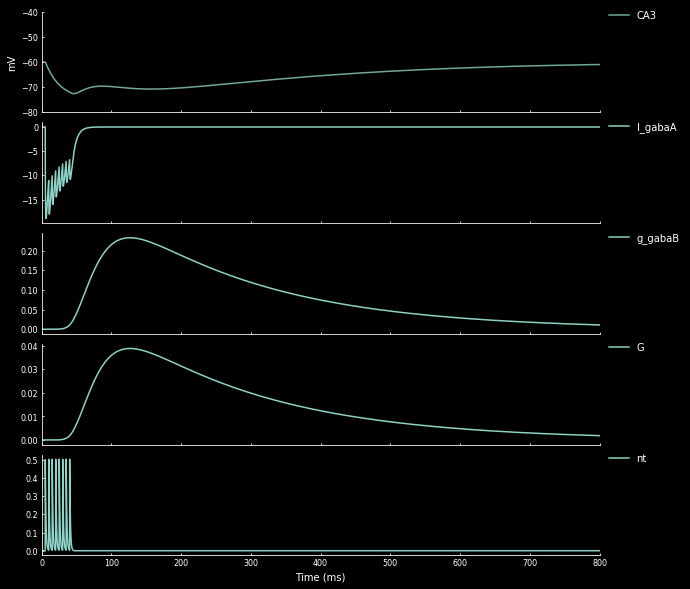

In [178]:
f, ax = plt.subplots(5, sharex=True, figsize=(10,10))
f.subplots_adjust(wspace=0.32, hspace=0.1)

ax[0].plot(stMCA3.t/ms, stMCA3.v[:1].T/mV, alpha=0.8, label='CA3')
ax[0].set_ylabel('mV')
ax[0].set_ylim(-80,-40)

#ax[1].plot(stMCA3.t/ms, -stMCA3.I_ampa[:1].T/pamp, label='I_ampa')
ax[1].plot(stMCA3.t/ms, -stMCA3.I_gabaA[:1].T/pamp, label='I_gabaA')
#ax[2].plot(stMCA3.t/ms, -stMCA3.I_gabaB[:1].T/pamp, label='I_gabaB')
ax[2].plot(stMCA3.t/ms, stMCA3.I_gabaB[:1].T/pamp/(stMCA3.v[:1].T - V_gabaB)*mV, label='g_gabaB')

G = stMCA3.G[0]
ax[3].plot(stMCA3.t/ms, G**4/(G**4+100), label='G')
#ax[3].plot(stMCA3.t/ms, stMCA3.f_gabaA[:1].T, label='f_gabaA')
#ax[3].plot(stMCA3.t/ms, stMCA3.f_gabaB[:1].T, label='f_gabaB')

ax[4].plot(stMCA3.t/ms, stMCA3.nt[:1].T, label='nt')

#ax[4].plot(spMCA3.t/ms, spMCA3.i, '.', color=cppaired[0], ms=2, label='CA3')

ax[-1].set_xlabel('Time (ms)')
for axis in list(ax.ravel()):# + axt:
    axis.set_xlim(0, runt)
    axis.spines["right"].set_visible(False)
    axis.spines["top"].set_visible(False)
    axis.tick_params(axis=u'both', which=u'both', length=2, direction='in', labelsize=8)
    axis.legend(frameon=False, bbox_to_anchor=(1.0, 0.9, 0.3, 0.2), loc='upper left')